In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing(as_frame=True)

df = data.frame

print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Records:")
print(df.duplicated().sum())

print("\nDescriptive Statistics:")
print(df.describe())

Dataset Shape: (20640, 9)

Column Names:
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

Missing Values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Duplicate Records:
0

Descriptive Statistics:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37

In [4]:
X = df.drop("MedHouseVal", axis=1)

y = df["MedHouseVal"]

print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)

Features:
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')

Target:
MedHouseVal


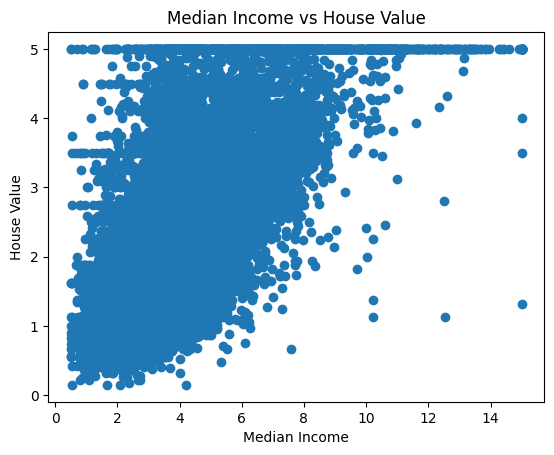

In [5]:
plt.scatter(df["MedInc"], df["MedHouseVal"])
plt.xlabel("Median Income")
plt.ylabel("House Value")
plt.title("Median Income vs House Value")
plt.show()

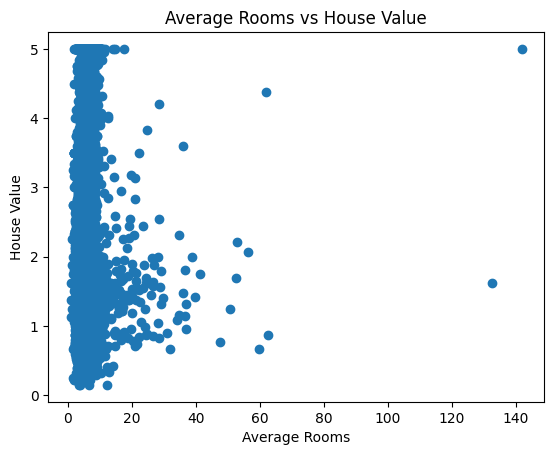

In [6]:
plt.scatter(df["AveRooms"], df["MedHouseVal"])
plt.xlabel("Average Rooms")
plt.ylabel("House Value")
plt.title("Average Rooms vs House Value")
plt.show()

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (16512, 8)
Testing data: (4128, 8)


In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [10]:
scaler.fit_transform(X_train)

array([[-0.326196  ,  0.34849025, -0.17491646, ...,  0.05137609,
        -1.3728112 ,  1.27258656],
       [-0.03584338,  1.61811813, -0.40283542, ..., -0.11736222,
        -0.87669601,  0.70916212],
       [ 0.14470145, -1.95271028,  0.08821601, ..., -0.03227969,
        -0.46014647, -0.44760309],
       ...,
       [-0.49697313,  0.58654547, -0.60675918, ...,  0.02030568,
        -0.75500738,  0.59946887],
       [ 0.96545045, -1.07984112,  0.40217517, ...,  0.00707608,
         0.90651045, -1.18553953],
       [-0.68544764,  1.85617335, -0.85144571, ..., -0.08535429,
         0.99543676, -1.41489815]])

In [11]:
scaler.transform(X_test)

array([[-1.15508475, -0.28632369, -0.52068576, ...,  0.06740798,
         0.1951    ,  0.28534728],
       [-0.70865905,  0.11043502, -0.16581537, ..., -0.03602975,
        -0.23549054,  0.06097472],
       [-0.21040155,  1.85617335, -0.61076476, ..., -0.14998876,
         1.00947776, -1.42487026],
       ...,
       [ 2.80902421, -0.28632369,  0.75501156, ..., -0.02646898,
         0.78014149, -1.23041404],
       [-0.57542978,  0.58654547, -0.06124296, ..., -0.04390537,
         0.52740357, -0.08860699],
       [-0.17259111, -0.92113763, -0.6058703 , ...,  0.05466644,
        -0.66608108,  0.60445493]])

In [12]:
linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

linear_pred = linear_model.predict(X_test_scaled)

In [13]:
linear_mae = mean_absolute_error(y_test, linear_pred)
linear_mse = mean_squared_error(y_test, linear_pred)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression")
print("MAE:", linear_mae)
print("MSE:", linear_mse)
print("RMSE:", linear_rmse)
print("R2 Score:", linear_r2)

Linear Regression
MAE: 0.5332001304956565
MSE: 0.5558915986952442
RMSE: 0.7455813830127763
R2 Score: 0.575787706032451


In [14]:
lasso = Lasso()

lasso_params = {
    "alpha": [0.001, 0.01, 0.1, 1, 10, 100]
}

lasso_grid = GridSearchCV(
    lasso,
    lasso_params,
    cv=5,
    scoring="neg_mean_squared_error"
)

lasso_grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10, 100]},
             scoring='neg_mean_squared_error')

In [15]:
print("Best Lasso Alpha:", lasso_grid.best_params_["alpha"])

Best Lasso Alpha: 0.001


In [16]:
lasso_model = lasso_grid.best_estimator_

lasso_pred = lasso_model.predict(X_test_scaled)

In [17]:
lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, lasso_pred)

print("Lasso Regression")
print("MAE:", lasso_mae)
print("MSE:", lasso_mse)
print("RMSE:", lasso_rmse)
print("R2 Score:", lasso_r2)

Lasso Regression
MAE: 0.5331447750392391
MSE: 0.5544913600832686
RMSE: 0.7446417662764214
R2 Score: 0.5768562568705682


In [19]:
ridge = Ridge()

ridge_params = {
    "alpha": [0.001, 0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    ridge,
    ridge_params,
    cv=5,
    scoring="neg_mean_squared_error"
)

ridge_grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10, 100]},
             scoring='neg_mean_squared_error')

In [20]:
print("Best Ridge Alpha:", ridge_grid.best_params_["alpha"])

Best Ridge Alpha: 0.1


In [21]:
ridge_model = ridge_grid.best_estimator_

ridge_pred = ridge_model.predict(X_test_scaled)

In [22]:
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression")
print("MAE:", ridge_mae)
print("MSE:", ridge_mse)
print("RMSE:", ridge_rmse)
print("R2 Score:", ridge_r2)

Ridge Regression
MAE: 0.5331994146968931
MSE: 0.5558879138674184
RMSE: 0.7455789118982769
R2 Score: 0.5757905180002312


In [23]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Linear Regression": linear_model.coef_,
    "Lasso Regression": lasso_model.coef_,
    "Ridge Regression": ridge_model.coef_
})

print(coefficients)

      Feature  Linear Regression  Lasso Regression  Ridge Regression
0      MedInc           0.854383          0.849140          0.854377
1    HouseAge           0.122546          0.123346          0.122554
2    AveRooms          -0.294410         -0.281273         -0.294390
3   AveBedrms           0.339259          0.326050          0.339234
4  Population          -0.002308         -0.001062         -0.002305
5    AveOccup          -0.040829         -0.039890         -0.040829
6    Latitude          -0.896929         -0.885822         -0.896853
7   Longitude          -0.869842         -0.858093         -0.869765


In [24]:
zero_coefficients = coefficients[
    coefficients["Lasso Regression"] == 0
]

print("Features with zero Lasso coefficients:")
print(zero_coefficients)

Features with zero Lasso coefficients:
Empty DataFrame
Columns: [Feature, Linear Regression, Lasso Regression, Ridge Regression]
Index: []


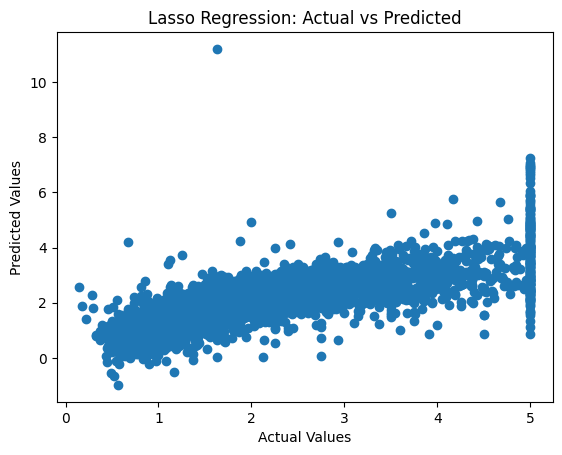

In [25]:
plt.scatter(y_test, lasso_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Lasso Regression: Actual vs Predicted")
plt.show()

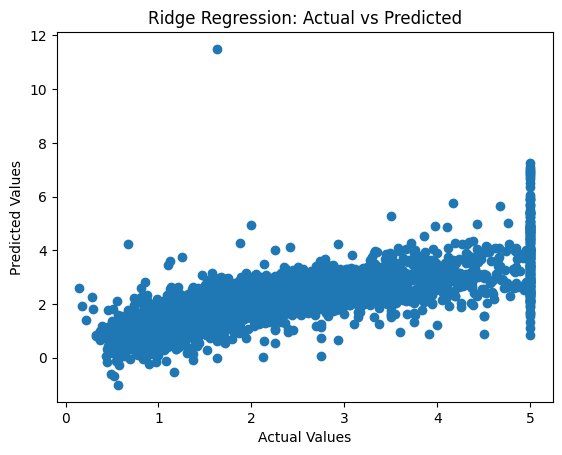

In [26]:
plt.scatter(y_test, ridge_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Ridge Regression: Actual vs Predicted")
plt.show()

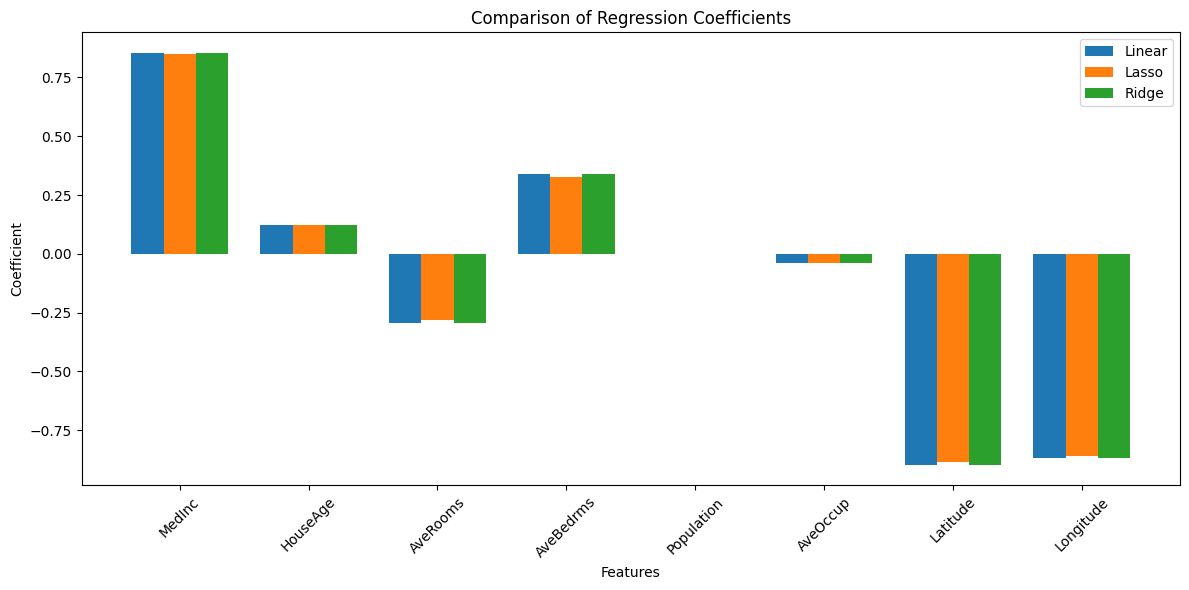

In [27]:
x = np.arange(len(X.columns))
width = 0.25

plt.figure(figsize=(12, 6))

plt.bar(x - width, linear_model.coef_, width, label="Linear")
plt.bar(x, lasso_model.coef_, width, label="Lasso")
plt.bar(x + width, ridge_model.coef_, width, label="Ridge")

plt.xticks(x, X.columns, rotation=45)
plt.xlabel("Features")
plt.ylabel("Coefficient")
plt.title("Comparison of Regression Coefficients")
plt.legend()
plt.tight_layout()
plt.show()

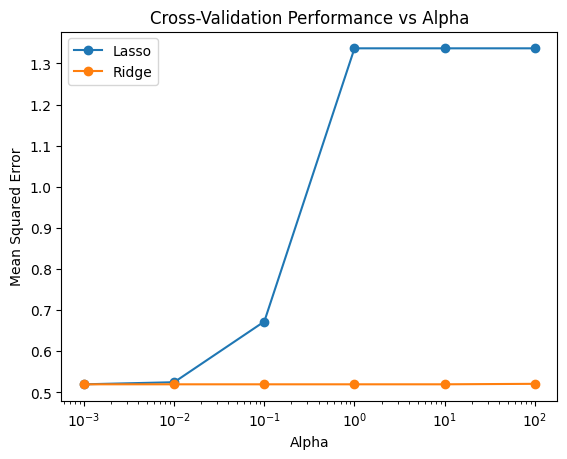

In [28]:
lasso_scores = -lasso_grid.cv_results_["mean_test_score"]

ridge_scores = -ridge_grid.cv_results_["mean_test_score"]

alphas = lasso_grid.cv_results_["param_alpha"].data.astype(float)

plt.plot(alphas, lasso_scores, marker="o", label="Lasso")
plt.plot(alphas, ridge_scores, marker="o", label="Ridge")

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Mean Squared Error")
plt.title("Cross-Validation Performance vs Alpha")
plt.legend()
plt.show()

In [29]:
print("Best Lasso Alpha:", lasso_grid.best_params_["alpha"])
print("Best Ridge Alpha:", ridge_grid.best_params_["alpha"])

Best Lasso Alpha: 0.001
Best Ridge Alpha: 0.1


In [32]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Lasso Regression", "Ridge Regression"],
    "MAE": [linear_mae, lasso_mae, ridge_mae],
    "MSE": [linear_mse, lasso_mse, ridge_mse],
    "RMSE": [linear_rmse, lasso_rmse, ridge_rmse],
    "R2 Score": [linear_r2, lasso_r2, ridge_r2]
})

print(results)

               Model       MAE       MSE      RMSE  R2 Score
0  Linear Regression  0.533200  0.555892  0.745581  0.575788
1   Lasso Regression  0.533145  0.554491  0.744642  0.576856
2   Ridge Regression  0.533199  0.555888  0.745579  0.575791


In [33]:
print("\nFinal Model Comparison")
print(results)

print("\nBest Lasso Alpha:", lasso_grid.best_params_["alpha"])
print("Best Ridge Alpha:", ridge_grid.best_params_["alpha"])

print("\nLasso Zero Coefficients:")
print(zero_coefficients)


Final Model Comparison
               Model       MAE       MSE      RMSE  R2 Score
0  Linear Regression  0.533200  0.555892  0.745581  0.575788
1   Lasso Regression  0.533145  0.554491  0.744642  0.576856
2   Ridge Regression  0.533199  0.555888  0.745579  0.575791

Best Lasso Alpha: 0.001
Best Ridge Alpha: 0.1

Lasso Zero Coefficients:
Empty DataFrame
Columns: [Feature, Linear Regression, Lasso Regression, Ridge Regression]
Index: []


INTERPRETATION

Alpha parameter regulates the extent of regularization; high alpha leads to greater regularization and shrinking of the coefficients.

Lasso Regression can reduce the coefficients to zero; thus, it helps select the important features. Ridge Regression shrinks the coefficients but does not drop any feature from the model.

Scaling of features is required since the range of features is not identical and it would lead to bias in regularization.

The GridSearchCV algorithm with 5-fold cross-validation has been applied to determine the optimal alpha values for Lasso and Ridge Regression. The models were analyzed based on their MAE, MSE, RMSE and R2 score values.

Regularization allows controlling the complexity of the model. The optimal model can be chosen based on the performance of Linear Regression, Lasso and Ridge on the test set.
